In [1]:
import os

arath_peps = set()  # arath_pep -> spectrum_name
pep2spec_name = dict()

In [2]:
def get_peptides(res_path):
    # pFind.Filtered.spectra
    peptides = set()
    f = open(res_path,"r")
    next(f,None)
    for line in f:
        items = line.strip().split("\t")
        seq = items[5]
        mod = items[10]
        peptide = seq+"\t"+mod
        peptides.add(peptide)
        proteins = items[12].strip("/").split("/")
        flag = True
        for protein in proteins:
            if not protein.endswith("_ARATH"):
                flag = False
                break
        if flag:
            arath_peps.add(peptide)
        pep2spec_name[peptide] = items[0]
        
    f.close()
    return peptides

def check(peptides):
    num = 0
    for pep in peptides:
        if pep in arath_peps:
            num += 1
    return num

In [3]:
# Astral
mgf_dir = "D:/workspace/data/ms/Astral/top50/"
target_res_path = "D:/workspace/pFindWorkspace/Astral/top50-complete/result/restricted/pFind-Filtered.spectra"
other_res_paths = ["D:/workspace/pFindWorkspace/Astral/top50-complete/result/dl_rt-0628/pFind-Filtered.spectra",
                 "D:/workspace/pFindWorkspace/Astral/top50-complete/result/dl_ms2-0628/pFind-Filtered.spectra",
                 "D:/workspace/pFindWorkspace/Astral/top50-complete/result/dl-0628/pFind-Filtered.spectra"
                ]
# # Gygi-QE
# target_res_path = "D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/restricted/pFind-Filtered.spectra"
# other_res_paths = ["D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/dl_rt-0628/pFind-Filtered.spectra",
#                  "D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/dl_ms2-0628/pFind-Filtered.spectra",
#                  "D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/dl-0628/pFind-Filtered.spectra"]
# # HLA
# target_res_path = "D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/restricted/pFind-Filtered.spectra"
# other_res_paths = ["D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/dl_rt-0628/pFind-Filtered.spectra",
#                  "D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/dl_ms2-0628/pFind-Filtered.spectra",
#                  "D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/dl-0628/pFind-Filtered.spectra"]
# Humangut


target_peptides = get_peptides(target_res_path)
infos = [len(target_peptides)]  # [ori, [shared,gained,loss],[shared,...],...]
arath_rates = list()
for res_path in other_res_paths:
    peptides = get_peptides(res_path)
    shared = target_peptides&peptides
    sa_num = check(shared)
    gained = peptides-target_peptides
    ga_num = check(gained)
    loss = target_peptides-peptides
    la_num = check(loss)
    arath_rates.append([ga_num/len(gained)*100,la_num/len(loss)*100])
    infos.append([len(shared),len(gained),len(loss)])

print(infos)
print(arath_rates)

[42619, [41841, 6018, 778], [41848, 6200, 771], [41997, 9918, 622]]
[[2.59222333000997, 15.295629820051415], [2.2258064516129035, 13.359273670557718], [1.7846339987900786, 20.739549839228296]]


[[1, [0.9817452310002581, 0.14120462704427603, 0.018254768999741898], [0.981909476993829, 0.14547502287712052, 0.018090523006170957], [0.9854055702855534, 0.2327131091766583, 0.014594429714446609]], [1, [0.9769516982809214, 0.06297969812137823, 0.023048301719078523], [0.9831055093703169, 0.0706719619831226, 0.016894490629683023], [0.9792878673055994, 0.10613614737237964, 0.0207121326944006]], [1, [0.9620069605568445, 0.1255800464037123, 0.03799303944315545], [0.9796017014694509, 0.24328112915699923, 0.02039829853054911], [0.9802784222737819, 0.29906225831399846, 0.019721577726218097]]]


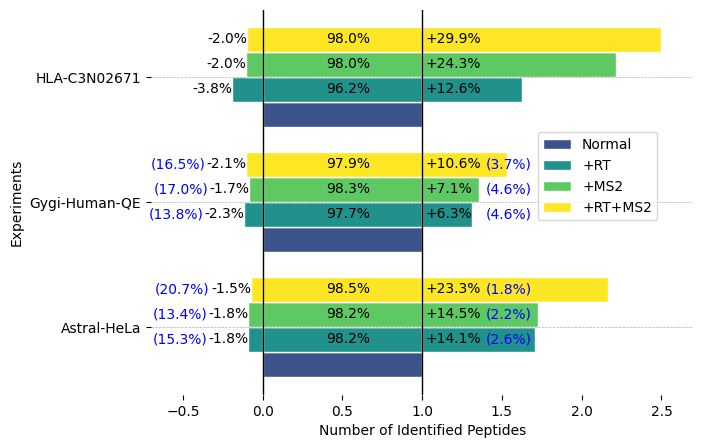

In [135]:
"""
图10: 修改细打分后selectpeak=5000，pepnum=10。
四簇直方图，每簇三个柱子，分别为修改粗打分前、修改粗打分后、修改细打分后，
粗打分进入top40、细打分进入top10、重打分排名为top1、通过FDR阈值的谱图数目堆叠图。
"""
import numpy as np
import matplotlib.pyplot as plt

scale = 5
# 示例数据：每个簇有3个柱子，每个柱子有3个堆叠部分
data = [
    [42619, [41841, 6018, 778], [41848, 6200, 771], [41997, 9918, 622]],  # Astral
    [175501, [171456, 11053, 4045], [172536, 12403, 2965], [171866, 18627, 3635]],
    [20688, [19902, 2598, 786], [20266, 5033, 422], [20280, 6187, 408]]  # HLA       
]
arath_rates = [
    [[2.59222333000997, 15.295629820051415], [2.2258064516129035, 13.359273670557717], [1.7846339987900786, 20.739549839228297]],
    [[4.568895322536868, 13.794808405438813], [4.603724905264856, 17.03204047217538], [3.6613518011488697, 16.451169188445666]]
]
    
for dd in data:
    total = dd[0]
    for i in range(1,4):
        dd[i][0] = dd[i][0]/total
        dd[i][1] = dd[i][1]/total
        dd[i][2] = dd[i][2]/total
    dd[0] = 1
print(data)

clusters = len(data)  # 有几组数据集
bars = len(data[0])   # 每个数据集有几组数据(默认第一个为target)
nums = 3  # 每组数据(第一组除外)有3个部分-shared,gained,loss
            
# 柱子的宽度和位置
bar_width = 0.4
cluster_positions = narange(clusters)*2  # 簇的位置，稍微间隔开 
indexes = np.arange(bars)*bar_width


# 创建一个图形和子图
fig, ax = plt.subplots(figsize=(7,5))

# 颜色列表
colors = ["#9d454e", "#cf9197", "#bfad72", "#e5dabc",]
# colors = ["#847A9F","#EEB2E3","#6072A5"]
# colors = ["#B63120", "#FB8122", "#E8D174"]
# colors = ["#F38181", "#FCE38A", "#95E1D3"]
# t = np.linspace(0, 1, 4)     
# cmap = plt.cm.get_cmap('plasma')
# colors = cmap(t) 
cmap = plt.cm.viridis
colors = [cmap(i/4) for i in range(1,5)]
# colors = ['#ffe6a7', '#ffbc70', '#ff8e3c', '#ff5e1a', '#d72c16', '#840032']  # 落日余晖
# colors = ['#f0fff4', '#c6f6d5', '#9ae6b4', '#68d391', '#48bb78', '#2f855a']  # 薄荷青柠
# colors = ['#d1edff', '#90d4ff', '#00aaff', '#0077ff', '#0055cc', '#002266']  # 深海蓝调
# colors = ['#fff5f7', '#ffcdd6', '#ffa3b9', '#ff85a1', '#f25f8c', '#d6336c']  # 樱花拿铁
# colors = ['#051937', '#004d7a', '#008793', '#00bf72', '#a8eb12']  # 极光青紫
# colors = ['#ffffff', '#e5e5e5', '#b8b8b8', '#888888', '#555555', '#222222']  # mono灰阶
# colors = ['#fffad1', '#ffc0f8', '#ff87e0', '#ff55c1', '#d433a5', '#8e1e8e']  # 热情火龙果
# colors = ['#fffac9', '#fff367', '#ffe94a', '#ffd92d', '#ffbb1c', '#ff8c00']  # 柠檬鲨

labels = ["Normal", "+RT", "+MS2", "+RT+MS2"]

# 绘制每个簇的堆叠柱子
for cluster_idx, cluster_data in enumerate(data):
    # 绘制该簇第一根柱子
    ax.barh(cluster_positions[cluster_idx], cluster_data[0], bar_width, 
                   label=labels[0] if cluster_idx==0 else None,
                   color=colors[0], edgecolor="white")
    # 绘制后续柱子(堆叠图)
    for stack_idx, stack_data in enumerate(cluster_data[1:]):
        shared,gained,loss = stack_data
        # shared = 1
        # shared
        ax.barh(cluster_positions[cluster_idx]+indexes[stack_idx+1], 1, bar_width, left=0,
                label=labels[stack_idx+1] if cluster_idx==0 else None,
                   color=colors[stack_idx+1], edgecolor="white")
        ax.text(0.4, cluster_positions[cluster_idx]+indexes[stack_idx+1]-0.05, f"{shared/cluster_data[0]*100:.1f}%", fontsize=10)
        # gained
        ax.barh(cluster_positions[cluster_idx]+indexes[stack_idx+1], gained*scale, bar_width, left=1,
                   # label=labels[stack_idx+1] if cluster_idx==0 and stack_idx==0 else None,
                   color=colors[stack_idx+1], edgecolor="white")
        ax.text(1.02, cluster_positions[cluster_idx]+indexes[stack_idx+1]-0.05, f"+{gained/cluster_data[0]*100:.1f}%", fontsize=10)
        # loss
        ax.barh(cluster_positions[cluster_idx]+indexes[stack_idx+1], -loss*scale, bar_width, left=0,
               # label=labels[stack_idx+1] if cluster_idx==0 and stack_idx==0 else None, 
               color=colors[stack_idx+1], edgecolor="white")
        ax.text(-loss*scale-0.25, cluster_positions[cluster_idx]+indexes[stack_idx+1]-0.05, f"-{loss/cluster_data[0]*100:.1f}%", fontsize=10)
        if cluster_idx < 2:
            ax.text(1.4, cluster_positions[cluster_idx]+indexes[stack_idx+1]-0.05, f"({arath_rates[cluster_idx][stack_idx][0]:.1f}%)", 
                    color="blue", fontsize=10)
            ax.text(-loss*scale-0.60, cluster_positions[cluster_idx]+indexes[stack_idx+1]-0.05, f"({arath_rates[cluster_idx][stack_idx][1]:.1f}%)", 
                    color="blue", fontsize=10)

# arath_rates = np.array(arath_rates)
# for i in range(len(arath_rates)):
#     for j in range(1,4):
#         ax.barh(cluster_positions[i]+j*bar_width, arath_rates[i,j-1,0]/5, bar_width, left=2.5, color=colors[j], hatch='x')
#         ax.barh(cluster_positions[i]+j*bar_width, -arath_rates[i,:,1]/50, bar_width, left=-0.5, color=colors[j], hatch='x')

# 添加标签和标题
ax.set_ylabel('Experiments')
ax.set_xlabel('Number of Identified Peptides')
ax.set_xlim([-0.7,2.7])
ax.set_title('')
ax.set_yticks(cluster_positions+0.6)  # 只设置第一个簇的X轴刻度位置作为示例
ax.set_yticklabels(["Astral-HeLa","Gygi-Human-QE","HLA-C3N02671"])  # 设置X轴刻度标签
# ax.legend(loc='upper right')  # 将图例放在图表外部以避免遮挡
# ax.legend(loc='upper right')
ax.legend(loc='upper left',           # 锚点取图例的“左上角”
          bbox_to_anchor=(0.7, 0.7))   # (x, y) 在 axes 坐标系
ax.grid(axis='y', linestyle='--', linewidth=0.5)

ax.axvline(0, color='black', linewidth=1)
ax.axvline(1, color='black', linewidth=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# 显示图表
# plt.tight_layout()  
plt.show()

In [42]:
"""
对于一个loss中落入陷阱库的肽段，以及谱图名
1. 在pFind-Filtered.spectra中找到新肽段，并判断是否属于arath_peps
2. 在mgf中找到谱图，写test.mgf
3. 写test.pepdata，并用pPred预测
"""
bad_pep = "FSSVSLNPSTR	0,Acetyl[ProteinN-term];"
spec_name = pep2spec_name[bad_pep]
flag = False
f = open(other_res_paths[-1], "r")
for line in f:
    items = line.split("\t")
    if spec_name == items[0]:
        new_pep = items[5]+"\t"+items[10]
        q_value = float(items[4])
        flag = True
        break
f.close()


if not flag:
    print("The lossed peptide is not found in new result")
elif new_pep in arath_peps:
    print(new_pep)
    print("new pep is falling into trapped library")
else:
    print(spec_name, new_pep, q_value)
    fw = open("D:/projects/pythonProjects/tools/data/draw_mirrored_spectrum/test2.mgf", "w")
    mgf_paths = [os.path.join(mgf_dir,filename) for filename in os.listdir(mgf_dir) if filename.endswith(".mgf")]
    for mgf_path in mgf_paths:  # 知道大概在哪个文件之后可以索引
        print(mgf_path)
        fr = open(mgf_path,"r")
        flag = False
        while True:
            line = fr.readline()
            if not line:
                break
            if line.startswith("T"):
                name = line.strip().split('=')[-1]
                if name == spec_name:
                    flag = True
                    fw.write(line)
                    while True:
                        line = fr.readline()
                        if line.startswith("T"):
                            break
                        elif line.startswith("C"):
                            charge = int(line.strip("+\n").split("=")[1])
                        fw.write(line)
                    break
        if flag:
            break
        fr.close()
    fw.close()
    print(f"charge={charge}")
    
    fw = open("D:/projects/pythonProjects/tools/data/draw_mirrored_spectrum/test2.pepdata", "w")
    fw.write("seq\tmod\n")
    fw.write(f"{new_pep}\t\t\t\t{1<<charge}\n")
    fw.write(f"{bad_pep}\t\t\t\t{1<<charge}\n")
    fw.close()
    print(spec_name)
    """
    pPred.exe -ms2 --pred -m D:\workspace\pFindWorkspace\Astral\top50-complete\result\dl-0628\finetuned_ms2.pt -d D:\projects\pythonProjects\tools\data\draw_mirrored_spectrum\test2.pepdata -op D:\projects\pythonProjects\tools\data\draw_mirrored_spectrum\test2.ms2data -i 1_28_28_28_2_6 -l D:\projects\pythonProjects\tools\data\draw_mirrored_spectrum\log.txt -bs 1024
    """

KeyError: 'QEMEELLYQYR'

In [91]:
"""
对于一个gained中落入陷阱库的肽段，以及谱图名
1. 在pFind-Filtered.spectra中找到旧肽段，并判断是否属于arath_peps(最好是)
2. 在mgf中找到谱图，写test.mgf
3. 写test.pepdata，并用pPred预测
"""
# spec_name2pep = dict()
# f = open(target_res_path.replace("pFind-Filtered.spectra","pFind.spectra"), "r")
# next(f,None)
# decoy = False
# for line in f:
#     items = line.strip().split("\t")
#     if len(items)<=6:
#         break
#     q_value = float(items[4])
#     decoy = (items[15]!="target")
#     old_pep = items[5]+"\t"+items[10]
#     spec_name2pep[items[0]] = [old_pep, q_value, decoy]
# f.close()


for i,p in enumerate(gained):
    if p in arath_peps:
        continue
    good_pep = p
        
    if i<=13:
        continue
    spec_name = pep2spec_name[good_pep]
    
    old_pep, q_value, decoy = spec_name2pep[spec_name]
    if old_pep != good_pep:  # old pep is not decoy
        # print(good_pep, old_pep, q_value)
        # print("old pep is not decoy")
        continue
    else:
        # 20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_02_20230808161140.29275.29275.2.0.dta QTIGLALQGK	 LLVVSGGDLR	 0.14482
        print(spec_name, good_pep, old_pep, q_value, i)
        fw = open("D:/projects/pythonProjects/tools/data/draw_mirrored_spectrum/test2.mgf", "w")
        mgf_paths = [os.path.join(mgf_dir,filename) for filename in os.listdir(mgf_dir) if filename.endswith(".mgf")]
        for mgf_path in mgf_paths[:]:  # 知道大概在哪个文件之后可以索引
            print(mgf_path)
            fr = open(mgf_path,"r")
            flag = False
            while True:
                line = fr.readline()
                if not line:
                    break
                if line.startswith("T"):
                    name = line.strip().split('=')[-1]
                    if name == spec_name:
                        flag = True
                        fw.write(line)
                        while True:
                            line = fr.readline()
                            if line.startswith("T"):
                                break
                            elif line.startswith("C"):
                                charge = int(line.strip("+\n").split("=")[1])
                            fw.write(line)
                        break
            if flag:
                break
            fr.close()
        fw.close()
        print(f"charge={charge}")
        
        fw = open("D:/projects/pythonProjects/tools/data/draw_mirrored_spectrum/test2.pepdata", "w")
        fw.write("seq\tmod\n")
        fw.write(f"{good_pep}\t\t\t\t{1<<charge}\n")
        fw.write(f"{old_pep}\t\t\t\t{1<<charge}\n")
        fw.close()
        print(spec_name)
        break
        """
        pPred.exe -ms2 --pred -m D:\workspace\pFindWorkspace\Astral\top50-complete\result\dl_ms2-0628\finetuned_ms2.pt -d D:\projects\pythonProjects\tools\data\draw_mirrored_spectrum\test2.pepdata -op D:\projects\pythonProjects\tools\data\draw_mirrored_spectrum\test2.ms2data -i 1_28_28_28_2_6 -l D:\projects\pythonProjects\tools\data\draw_mirrored_spectrum\log.txt -bs 1024
        """

20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_01_20230808155512.22122.22122.2.8.dta VLTDYYR	 VLTDYYR	 0.090854 14
D:/workspace/data/ms/Astral/top50/20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_01_20230808155512_HCDAST.mgf
charge=2
20230108_AST_Neo1_DDA_UHG_HeLa_200ng_2th2p5ms_top50_01_20230808155512.22122.22122.2.8.dta


In [ ]:
for peptide in gained:
    